# OGM Feature Model Analysis

## 1. Setup

This notebook only visualizes and statistically tests data - it does not run any simulations itself. Simulation logic and data generation live in `analysis.py`; run it first (`python analysis.py`) to populate `data/*.csv`, then re-run this notebook top to bottom whenever the data changes.

In [74]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy import stats

In [75]:
params = pd.read_csv("data/params.csv").set_index("name")["value"]

ALPHA = float(params["ALPHA"])
GAMMA = float(params["GAMMA"])
TEMP = float(params["TEMP"])
VALUE_DECAY = float(params["VALUE_DECAY"])
TRAUMA_VALENCE = float(params["TRAUMA_VALENCE"])
N_RETRIEVALS = int(params["N_RETRIEVALS"])
MAX_STEPS = int(params["MAX_STEPS"])
N_REPS = int(params["N_REPS"])
SWEEP_REPS = int(params["SWEEP_REPS"])
decay_rate_values = json.loads(params["decay_rate_values"])

## 2. Agent vs FeatureAgent Comparison

Direct comparison of the single-value `Agent` against the per-feature-value `FeatureAgent`: a single-run illustration with trauma-encounter markers (`single_run.png`), and the original network with one fixed trauma node from initialization (`comparison_1.png`). Data comes from `data/single_run.csv` and `data/comparison_1.csv` (generated by `analysis.py`). `mean_sem` and the statistical-testing helpers defined here are reused in section 3.

In [76]:
def mean_sem(arr):
    """Mean and standard error of the mean across reps (axis 0). SEM is 0 when
    there's only 1 rep."""
    mean = arr.mean(axis=0)
    reps = arr.shape[0]
    sem = arr.std(axis=0, ddof=1) / np.sqrt(reps) if reps > 1 else np.zeros_like(mean)
    return mean, sem


def sig_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def holm_bonferroni(pvals):
    """Holm-Bonferroni step-down correction. Controls the family-wise error
    rate (like Bonferroni) but is uniformly more powerful, so it's the
    standard default over a flat Bonferroni correction."""
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    adjusted = np.empty(m)
    running_max = 0.0
    for rank, idx in enumerate(order):
        running_max = max(running_max, (m - rank) * pvals[idx])
        adjusted[idx] = min(running_max, 1.0)
    return adjusted


def agent_vs_feature_table(param_values, param_name, dv_specs):
    """Welch's t-test (unequal variance) between Agent and FeatureAgent at
    each param value, for each (dv_name, agent_raw, feature_raw) triple in
    dv_specs, where *_raw is a list of per-rep arrays (one array per param
    value). Holm-Bonferroni correction is applied across every row of the
    returned table (i.e. across all param values and dependent variables
    passed in together)."""
    rows = []
    for dv_name, agent_raw, feature_raw in dv_specs:
        for value, a, f in zip(param_values, agent_raw, feature_raw):
            t, p = stats.ttest_ind(a, f, equal_var=False)
            rows.append({param_name: value, "dependent variable": dv_name,
                         "Agent mean": a.mean(), "FeatureAgent mean": f.mean(),
                         "t": t, "p": p})
    df = pd.DataFrame(rows)
    df["p (Holm-adj)"] = holm_bonferroni(df["p"])
    df[""] = df["p (Holm-adj)"].apply(sig_stars)
    return df


def across_values_table(param_name, agent_name_specs):
    """One-way ANOVA across all param values, for each (agent_name, dv_name,
    raw_by_value) triple in agent_name_specs, where raw_by_value is a list of
    per-rep arrays (one array per param value). Holm-Bonferroni correction is
    applied across every row of the returned table."""
    rows = []
    for agent_name, dv_name, raw_by_value in agent_name_specs:
        f, p = stats.f_oneway(*raw_by_value)
        rows.append({"agent": agent_name, "dependent variable": dv_name, "F": f, "p": p})
    df = pd.DataFrame(rows)
    df["p (Holm-adj)"] = holm_bonferroni(df["p"])
    df[""] = df["p (Holm-adj)"].apply(sig_stars)
    return df


def pairwise_across_values_table(param_values, param_name, agent_name_specs):
    """Pairwise post-hoc Welch's t-tests between every pair of param_values,
    for each (agent_name, dv_name, raw_by_value) triple in agent_name_specs
    (raw_by_value is a list of per-rep arrays, one per param value). These
    follow up the omnibus ANOVA in across_values_table by localizing which
    specific pair(s) of param values differ. Holm-Bonferroni correction is
    applied separately within each (agent_name, dv_name) group of pairwise
    comparisons, since each group answers a distinct question and shouldn't
    dilute another group's error budget."""
    groups = []
    for agent_name, dv_name, raw_by_value in agent_name_specs:
        group_rows = []
        for (i, vi), (j, vj) in combinations(enumerate(param_values), 2):
            t, p = stats.ttest_ind(raw_by_value[i], raw_by_value[j], equal_var=False)
            group_rows.append({"agent": agent_name, "dependent variable": dv_name,
                                f"{param_name} A": vi, f"{param_name} B": vj,
                                "t": t, "p": p})
        group_df = pd.DataFrame(group_rows)
        group_df["p (Holm-adj)"] = holm_bonferroni(group_df["p"])
        group_df[""] = group_df["p (Holm-adj)"].apply(sig_stars)
        groups.append(group_df)
    return pd.concat(groups, ignore_index=True)

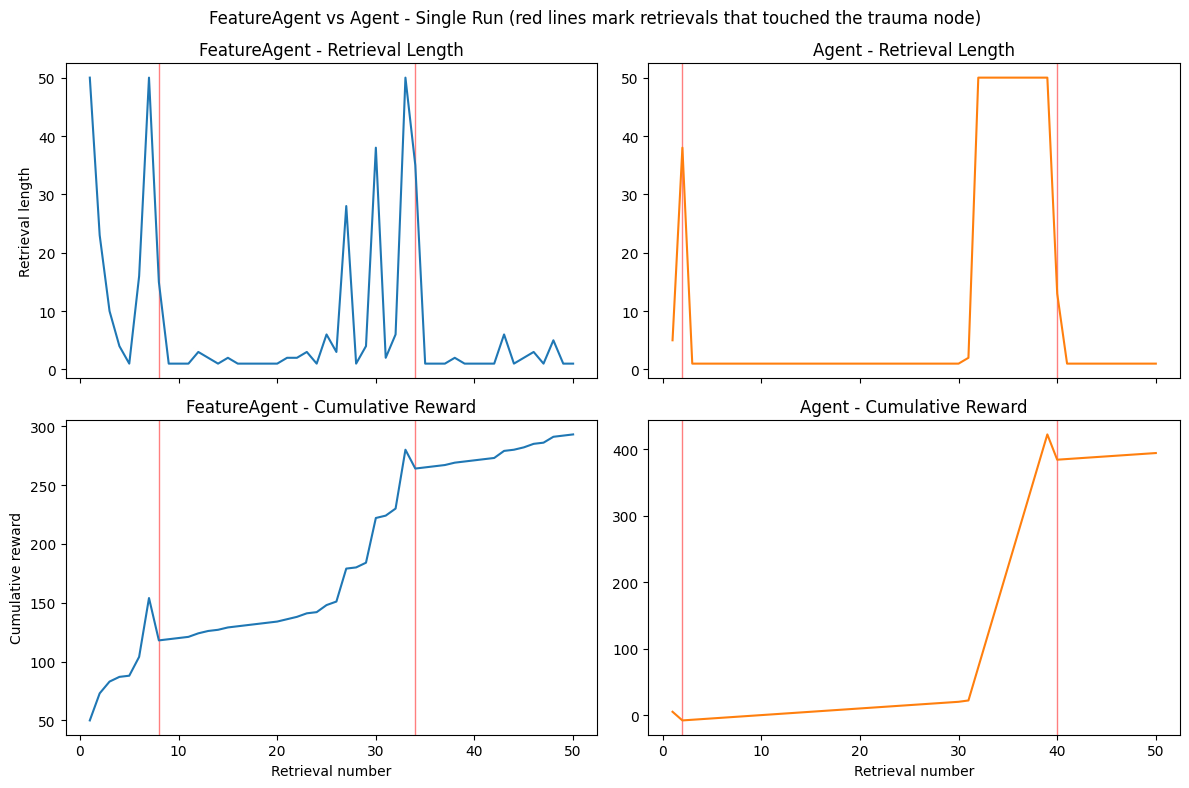

In [77]:
single_run_df = pd.read_csv("data/single_run.csv")
feature_1 = single_run_df[single_run_df.agent_type == "FeatureAgent"].sort_values("retrieval_num")
agent_1 = single_run_df[single_run_df.agent_type == "Agent"].sort_values("retrieval_num")

retrieval_num_1 = feature_1["retrieval_num"].to_numpy()
feature_lengths_1 = feature_1["length"].to_numpy()
feature_trauma_1 = feature_1["trauma_encounter"].to_numpy(dtype=bool)
agent_lengths_1 = agent_1["length"].to_numpy()
agent_trauma_1 = agent_1["trauma_encounter"].to_numpy(dtype=bool)

feature_cumulative_reward_1 = np.cumsum(feature_1["reward"].to_numpy())
agent_cumulative_reward_1 = np.cumsum(agent_1["reward"].to_numpy())

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axs[0][0].plot(retrieval_num_1, feature_lengths_1, color="C0")
axs[0][0].set_title("FeatureAgent - Retrieval Length")
axs[0][0].set_ylabel("Retrieval length")
axs[0][1].plot(retrieval_num_1, agent_lengths_1, color="C1")
axs[0][1].set_title("Agent - Retrieval Length")

axs[1][0].plot(retrieval_num_1, feature_cumulative_reward_1, color="C0")
axs[1][0].set_title("FeatureAgent - Cumulative Reward")
axs[1][0].set_ylabel("Cumulative reward")
axs[1][0].set_xlabel("Retrieval number")
axs[1][1].plot(retrieval_num_1, agent_cumulative_reward_1, color="C1")
axs[1][1].set_title("Agent - Cumulative Reward")
axs[1][1].set_xlabel("Retrieval number")

for ax, hits in [(axs[0][0], feature_trauma_1), (axs[1][0], feature_trauma_1),
                  (axs[0][1], agent_trauma_1), (axs[1][1], agent_trauma_1)]:
    for x in retrieval_num_1[hits]:
        ax.axvline(x, color="red", alpha=0.5, linewidth=1, zorder=0)

fig.suptitle("FeatureAgent vs Agent - Single Run (red lines mark retrievals that touched the trauma node)")
plt.tight_layout()
plt.savefig("plots/single_run.png")
plt.show()

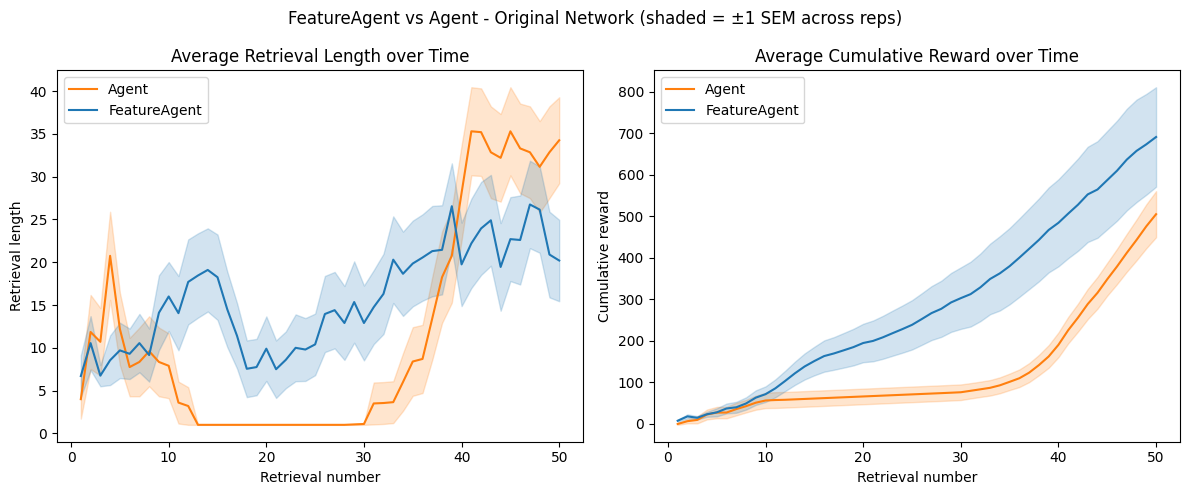

In [78]:
comparison_df = pd.read_csv("data/comparison_1.csv")

def pivot_metric(df, agent_type, metric):
    sub = df[df.agent_type == agent_type].pivot(index="rep", columns="retrieval_num", values=metric)
    return sub.sort_index(axis=1).to_numpy()

feature_lengths = pivot_metric(comparison_df, "FeatureAgent", "length")
feature_rewards = pivot_metric(comparison_df, "FeatureAgent", "reward")
agent_lengths = pivot_metric(comparison_df, "Agent", "length")
agent_rewards = pivot_metric(comparison_df, "Agent", "reward")

retrieval_num = np.arange(1, feature_lengths.shape[1] + 1)

feature_cumulative_rewards = np.cumsum(feature_rewards, axis=1)
agent_cumulative_rewards = np.cumsum(agent_rewards, axis=1)

feature_length_mean, feature_length_sem = mean_sem(feature_lengths)
agent_length_mean, agent_length_sem = mean_sem(agent_lengths)
feature_cum_mean, feature_cum_sem = mean_sem(feature_cumulative_rewards)
agent_cum_mean, agent_cum_sem = mean_sem(agent_cumulative_rewards)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(retrieval_num, agent_length_mean, label="Agent", color="C1")
axs[0].fill_between(retrieval_num, agent_length_mean - agent_length_sem, agent_length_mean + agent_length_sem, color="C1", alpha=0.2)
axs[0].plot(retrieval_num, feature_length_mean, label="FeatureAgent", color="C0")
axs[0].fill_between(retrieval_num, feature_length_mean - feature_length_sem, feature_length_mean + feature_length_sem, color="C0", alpha=0.2)
axs[0].set_xlabel("Retrieval number")
axs[0].set_ylabel("Retrieval length")
axs[0].set_title("Average Retrieval Length over Time")
axs[0].legend()

axs[1].plot(retrieval_num, agent_cum_mean, label="Agent", color="C1")
axs[1].fill_between(retrieval_num, agent_cum_mean - agent_cum_sem, agent_cum_mean + agent_cum_sem, color="C1", alpha=0.2)
axs[1].plot(retrieval_num, feature_cum_mean, label="FeatureAgent", color="C0")
axs[1].fill_between(retrieval_num, feature_cum_mean - feature_cum_sem, feature_cum_mean + feature_cum_sem, color="C0", alpha=0.2)
axs[1].set_xlabel("Retrieval number")
axs[1].set_ylabel("Cumulative reward")
axs[1].set_title("Average Cumulative Reward over Time")
axs[1].legend()

fig.suptitle("FeatureAgent vs Agent - Original Network (shaded = ±1 SEM across reps)")
plt.tight_layout()
plt.savefig("plots/comparison_1.png")
plt.show()

## 3. Decay Rate Sweep (Agent vs FeatureAgent)

Compares average retrieval length across `decay_rate` - 0 (no decay), 0.01, 0.02 - for both `Agent` and `FeatureAgent` on the original network (`decay_rate_1.png`). `decay_rate_values` matches Kato & Morita's (2016, *PLOS Comp Biol* e1005145) explored phi/kappa no-decay-to-decay range; `ALPHA`/`GAMMA`/`TEMP` stay at their global defaults (loaded from `data/params.csv`) throughout. Data comes from `data/decay_rate_sweep.csv`. Cumulative reward is intentionally excluded here - it tracks the same underlying effect as retrieval length and is redundant with it (see section 2's plots for cumulative reward).

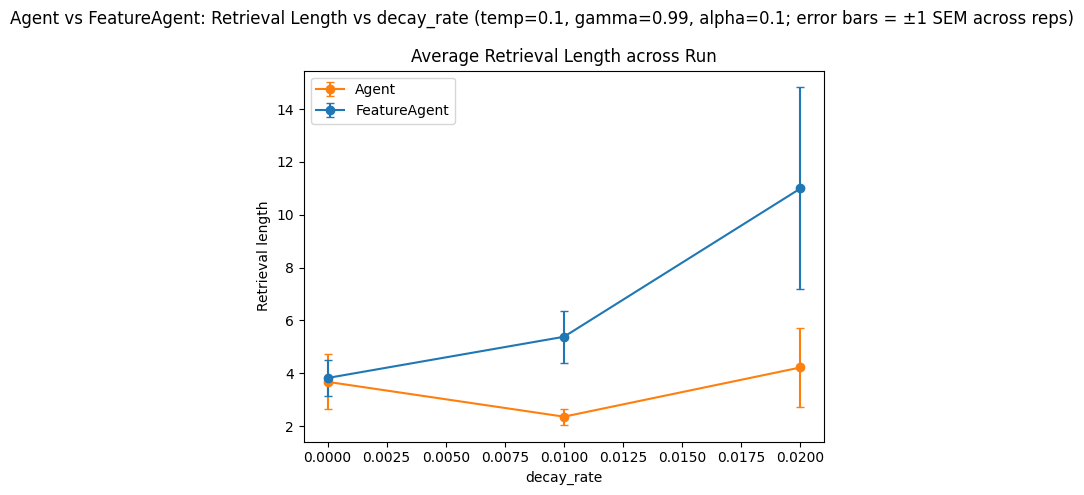

In [79]:
decay_df = pd.read_csv("data/decay_rate_sweep.csv")

def raw_by_decay_rate(df, agent_type):
    sub = df[df.agent_type == agent_type]
    return [sub[sub.decay_rate == dr]["avg_retrieval_length"].to_numpy() for dr in decay_rate_values]

agent_raw_avg_len = raw_by_decay_rate(decay_df, "Agent")
feature_raw_avg_len = raw_by_decay_rate(decay_df, "FeatureAgent")

agent_avg_len_mean, agent_avg_len_sem = mean_sem(np.array(agent_raw_avg_len).T)
feature_avg_len_mean, feature_avg_len_sem = mean_sem(np.array(feature_raw_avg_len).T)

fig, ax = plt.subplots(figsize=(6, 5))
ax.errorbar(decay_rate_values, agent_avg_len_mean, yerr=agent_avg_len_sem, marker="o", capsize=3, label="Agent", color="C1")
ax.errorbar(decay_rate_values, feature_avg_len_mean, yerr=feature_avg_len_sem, marker="o", capsize=3, label="FeatureAgent", color="C0")
ax.set_xlabel("decay_rate")
ax.set_ylabel("Retrieval length")
ax.set_title("Average Retrieval Length across Run")
ax.legend()

fig.suptitle(f"Agent vs FeatureAgent: Retrieval Length vs decay_rate "
             f"(temp={TEMP}, gamma={GAMMA}, alpha={ALPHA}; error bars = ±1 SEM across reps)")
plt.tight_layout()
plt.savefig("plots/decay_rate_1.png")
plt.show()

In [80]:
# Statistical tests accompanying the plot above.
# 1) Agent vs FeatureAgent at each decay_rate (Welch's t-test, unequal variance).
# 2) Across decay_rate values, within each agent type (one-way ANOVA, 3 levels).
# 3) Pairwise post-hoc comparisons between each pair of decay_rate values,
#    within each agent, to localize which specific pair(s) the ANOVA picked up on.
# Only average retrieval length is tested (cumulative reward dropped - see the
# sweep cell above). Every table's p-values are Holm-Bonferroni corrected (see
# holm_bonferroni above) within that table - see each table's print statement
# for exactly which set of tests share a correction (the family-wise error budget).
pd.set_option("display.float_format", lambda x: f"{x:.4g}")

agent_vs_feature = agent_vs_feature_table(
    decay_rate_values, "decay_rate",
    [("avg retrieval length", agent_raw_avg_len, feature_raw_avg_len)])
print("Agent vs FeatureAgent, at each decay_rate (Welch's t-test, Holm-adjusted across all 3 tests):")
display(agent_vs_feature)

across_decay = across_values_table(
    "decay_rate",
    [("Agent", "avg retrieval length", agent_raw_avg_len),
     ("FeatureAgent", "avg retrieval length", feature_raw_avg_len)])
print("\nAcross decay_rate values, within each agent (one-way ANOVA, Holm-adjusted across both tests):")
display(across_decay)

pairwise_decay = pairwise_across_values_table(
    decay_rate_values, "decay_rate",
    [("Agent", "avg retrieval length", agent_raw_avg_len),
     ("FeatureAgent", "avg retrieval length", feature_raw_avg_len)])
print("\nPairwise decay_rate comparisons, within each agent (Welch's t-test, Holm-adjusted "
      "within each agent's group of 3 pairwise tests):")
display(pairwise_decay)

Agent vs FeatureAgent, at each decay_rate (Welch's t-test, Holm-adjusted across all 3 tests):


,decay_rate,dependent variable,Agent mean,FeatureAgent mean,t,p,p (Holm-adj),
0,0,avg retrieval length,3.676,3.822,-0.1165,0.9087,0.9087,ns
1,0.01,avg retrieval length,2.358,5.382,-2.927,0.01416,0.04247,*
2,0.02,avg retrieval length,4.22,10.99,-1.653,0.1251,0.2502,ns



Across decay_rate values, within each agent (one-way ANOVA, Holm-adjusted across both tests):


,agent,dependent variable,F,p,p (Holm-adj),
0,Agent,avg retrieval length,0.8137,0.4538,0.4538,ns
1,FeatureAgent,avg retrieval length,2.658,0.08839,0.1768,ns



Pairwise decay_rate comparisons, within each agent (Welch's t-test, Holm-adjusted within each agent's group of 3 pairwise tests):


,agent,dependent variable,decay_rate A,decay_rate B,t,p,p (Holm-adj),
0,Agent,avg retrieval length,0,0.01,1.211,0.2526,0.7412,ns
1,Agent,avg retrieval length,0,0.02,-0.3001,0.768,0.768,ns
2,Agent,avg retrieval length,0.01,0.02,-1.231,0.2471,0.7412,ns
3,FeatureAgent,avg retrieval length,0,0.01,-1.295,0.2137,0.37,ns
4,FeatureAgent,avg retrieval length,0,0.02,-1.847,0.09586,0.2876,ns
5,FeatureAgent,avg retrieval length,0.01,0.02,-1.422,0.185,0.37,ns
